
## Imports 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


# MODULE 3 : Clustering — Analyse Non-Supervisée


###  Préparation des données 

In [2]:
df_clean = pd.read_csv("../data/df_clean.csv")

### Features pour clustering

In [3]:
cols_to_remove = ['Categorie', 'Prix_Revente', 'Rapport_Collecte']

X = df_clean.drop(columns=[c for c in cols_to_remove if c in df_clean.columns])

print("Features utilisées :", X.columns.tolist())
print("Shape X :", X.shape)

Features utilisées : ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Source']
Shape X : (4156, 6)


### Scaling

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Mean après scaling:", X_scaled.mean())

Mean après scaling: 7.62232041289007e-18


### ELBOW METHOD

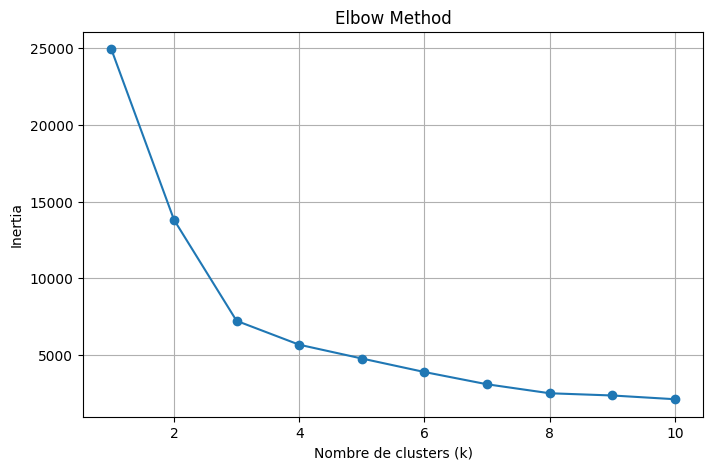

In [5]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# plot
plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertia")
plt.grid()
plt.show()

### SILHOUETTE SCORE

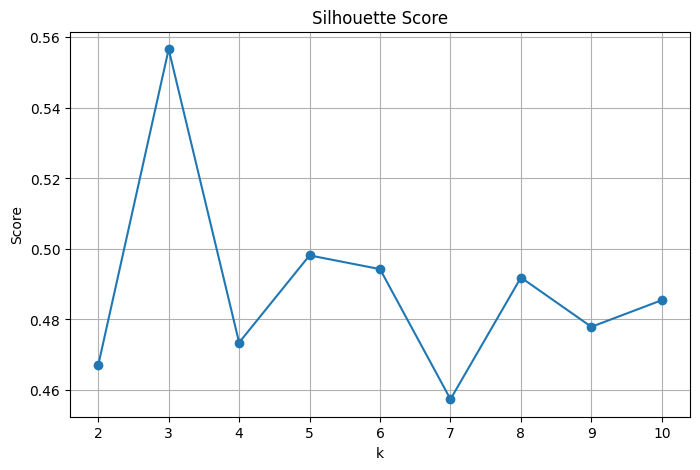

In [22]:
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(k_range, sil_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("k")
plt.ylabel("Score")
plt.grid()
plt.show()

### CHOIX DU K OPTIMAL

In [23]:
best_k = k_range[np.argmax(sil_scores)]

print("Meilleur k (Silhouette):", best_k)
print("Score max:", max(sil_scores))

Meilleur k (Silhouette): 3
Score max: 0.5566305752284616


### KMEANS 

In [24]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_clean['Cluster'] = clusters

print(df_clean['Cluster'].value_counts())

Cluster
1    2115
2    1084
0     957
Name: count, dtype: int64


### PCA (2D)

In [25]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Variance expliquée:", pca.explained_variance_ratio_)

Variance expliquée: [0.5031939  0.26366951]


### Visualisation

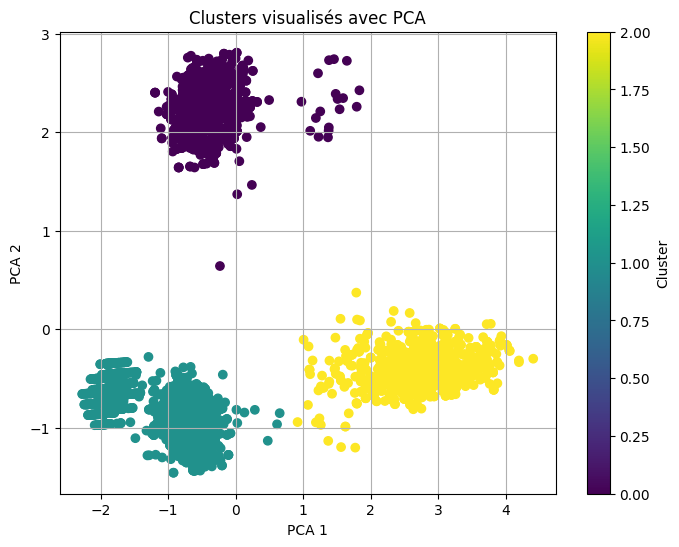

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df_clean['Cluster'],
    cmap='viridis'
)

plt.title("Clusters visualisés avec PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label="Cluster")
plt.grid()

plt.show()

### SCREE PLOT PCA

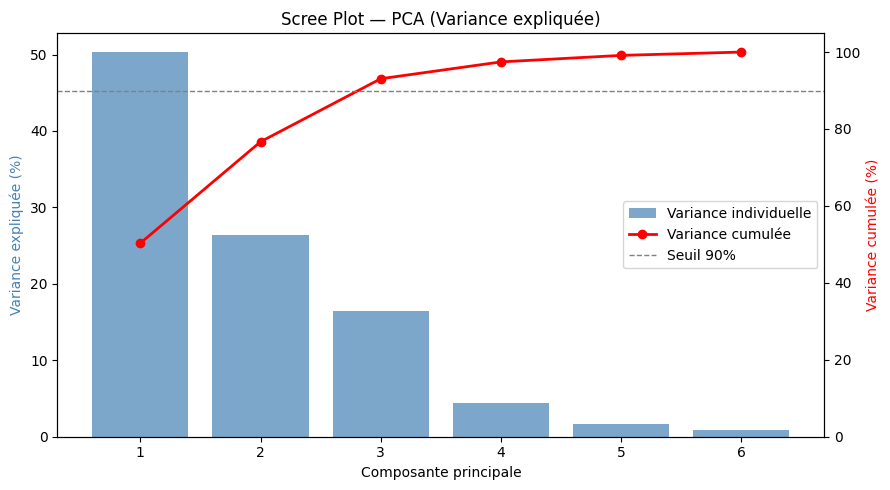

In [ ]:

# PCA + SCREE PLOT PRO
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# PCA complet
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

# variance expliquée
indvar = pca_full.explained_variance_ratio_ * 100
cumvar = np.cumsum(indvar)

# PLOT
fig, ax1 = plt.subplots(figsize=(9, 5))

# barres (variance individuelle)
ax1.bar(
    range(1, len(indvar) + 1),
    indvar,
    color='steelblue',
    alpha=0.7,
    label='Variance individuelle'
)

ax1.set_xlabel('Composante principale')
ax1.set_ylabel('Variance expliquée (%)', color='steelblue')
ax1.set_xticks(range(1, len(indvar) + 1))

# ligne cumulée
ax2 = ax1.twinx()
ax2.plot(
    range(1, len(cumvar) + 1),
    cumvar,
    'ro-',
    linewidth=2,
    markersize=6,
    label='Variance cumulée'
)

# seuil 90%
ax2.axhline(
    y=90,
    color='gray',
    linestyle='--',
    linewidth=1,
    label='Seuil 90%'
)

ax2.set_ylabel('Variance cumulée (%)', color='red')
ax2.set_ylim(0, 105)

# légende combinée
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.title('Scree Plot — PCA (Variance expliquée)')
plt.tight_layout()
plt.show()